# 1. Training Set Preprocessing

## 1.1 Data Loading

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import matplotlib.ticker as ticker
import joblib
from scipy import stats
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler

# 1. Data Loading
# January 2025 - November 2025 as the training set
new_train_files = glob.glob('/Users/yanmingkuang/Desktop/IDX/CRMLSSold20250[1-9].csv') + \
              glob.glob('/Users/yanmingkuang/Desktop/IDX/CRMLSSold20251[0-1].csv')

print("Number of training files found:", len(new_train_files))
print("Files:", new_train_files)

new_train_df_list = []
for file in new_train_files:
    temp_new_train_df = pd.read_csv(file,low_memory=False)
    new_train_df_list.append(temp_new_train_df)

new_train_df = pd.concat(new_train_df_list, ignore_index=True)

print("Dataset shape:", new_train_df.shape)



Number of training files found: 11
Files: ['/Users/yanmingkuang/Desktop/IDX/CRMLSSold202509.csv', '/Users/yanmingkuang/Desktop/IDX/CRMLSSold202508.csv', '/Users/yanmingkuang/Desktop/IDX/CRMLSSold202503.csv', '/Users/yanmingkuang/Desktop/IDX/CRMLSSold202502.csv', '/Users/yanmingkuang/Desktop/IDX/CRMLSSold202501.csv', '/Users/yanmingkuang/Desktop/IDX/CRMLSSold202505.csv', '/Users/yanmingkuang/Desktop/IDX/CRMLSSold202504.csv', '/Users/yanmingkuang/Desktop/IDX/CRMLSSold202506.csv', '/Users/yanmingkuang/Desktop/IDX/CRMLSSold202507.csv', '/Users/yanmingkuang/Desktop/IDX/CRMLSSold202511.csv', '/Users/yanmingkuang/Desktop/IDX/CRMLSSold202510.csv']
Dataset shape: (239566, 80)


## 1.2 Data Cleaning

In [80]:
# 2. Data cleaning

# 2.1 Restrict to single-family residential homes
# Keep backup before filtering
train_raw = new_train_df.copy()

# Apply the filter
new_train_df = new_train_df[
    (new_train_df['PropertyType'] == 'Residential') & 
    (new_train_df['PropertySubType'] == 'SingleFamilyResidence')
].copy()

print(f"Filtered to single-family: {new_train_df.shape[0]:,} rows")


# 2.2 Remove top 0.5% and bottom 0.5% of ClosePrice to exclude erroneous / non-economic transactions

lower_threshold = new_train_df['ClosePrice'].quantile(0.005)   # bottom 0.5%
upper_threshold = new_train_df['ClosePrice'].quantile(0.995)   # top 0.5%

print(f"\nOutlier removal thresholds (ClosePrice):")
print(f"  Lower (0.5th percentile): ${lower_threshold:,.0f}")
print(f"  Upper (99.5th percentile): ${upper_threshold:,.0f}")

rows_before = len(new_train_df)
low_outliers  = new_train_df['ClosePrice'] < lower_threshold
high_outliers = new_train_df['ClosePrice'] > upper_threshold

print(f"Rows removed (bottom 0.5%): {low_outliers.sum():,}")
print(f"Rows removed (top 0.5%):    {high_outliers.sum():,}")
print(f"Total rows removed:         {low_outliers.sum() + high_outliers.sum():,}")
print(f"Percentage removed:         {((low_outliers.sum() + high_outliers.sum()) / rows_before) * 100:.3f}%")

new_train_df = new_train_df[
    (new_train_df['ClosePrice'] >= lower_threshold) & 
    (new_train_df['ClosePrice'] <= upper_threshold)
].copy()


# 2.3 Exclude `ListPrice` , `OriginalListPrice`, 'DaysOnMarket'
columns_to_drop = ['ListPrice', 'OriginalListPrice','DaysOnMarket']
new_train_df = new_train_df.drop(columns=columns_to_drop, errors='ignore')


# 2.4 Remove rows where LivingArea is <=0
print("Rows with LivingArea == 0:", (new_train_df['LivingArea'] <= 0).sum())
new_train_df = new_train_df[new_train_df['LivingArea'] > 0].copy()


# 2.5 Remove rows where Latitude or Longitude is missing or invalid

print("\nInvalid Latitude (outside CA range or 0/NaN):")
print(new_train_df[~new_train_df['Latitude'].between(32.5, 42.0)]['Latitude'].value_counts(dropna=False))

print("\nInvalid Longitude (outside CA range or 0/NaN):")
print(new_train_df[~new_train_df['Longitude'].between(-124.5, -114.0)]['Longitude'].value_counts(dropna=False))

lat_min, lat_max = 32.5, 42.0
lon_min, lon_max = -124.5, -114.0

valid_location = (
    new_train_df['Latitude'].notna() &
    new_train_df['Longitude'].notna() &
    new_train_df['Latitude'].between(lat_min, lat_max) &
    new_train_df['Longitude'].between(lon_min, lon_max)
)

new_train_df = new_train_df[valid_location].copy()

# 2.6 remove illogical/impossible values
logical_values = (
    (new_train_df['BedroomsTotal'] > 0) &
    (new_train_df['BathroomsTotalInteger'] > 0) &
    (new_train_df['LotSizeAcres'] > 0) &
    (new_train_df['LotSizeArea'] > 0) &
    (new_train_df['LotSizeSquareFeet'] > 0) &
    (new_train_df['ParkingTotal'] >= 0) &  # >= 0 to allow 0, only drop negative
    (new_train_df['LotSizeSquareFeet'] <= 217800) & #realistic max (e.g., 5 acres = 217,800 sq ft)
    (new_train_df['ParkingTotal'] <= 50) &
    (new_train_df['GarageSpaces'].isna() | new_train_df['GarageSpaces'] <= 100) # keep the missing rows
)


# Apply the filter
new_train_df = new_train_df[logical_values].copy()

print("\nUpdated min values after removal:")
print("BedroomsTotal min:      ", new_train_df['BedroomsTotal'].min())
print("BathroomsTotalInteger min:", new_train_df['BathroomsTotalInteger'].min())
print("LotSizeAcres min:       ", new_train_df['LotSizeAcres'].min())
print("LotSizeArea min:        ", new_train_df['LotSizeArea'].min())
print("LotSizeSquareFeet min:  ", new_train_df['LotSizeSquareFeet'].min())
print("ParkingTotal min:       ", new_train_df['ParkingTotal'].min())
print("LotSizeSquareFeet max:  ", new_train_df['LotSizeSquareFeet'].max())
print("ParkingTotal max:       ", new_train_df['ParkingTotal'].max())
print("GarageSpaces max:       ", new_train_df['GarageSpaces'].max())

# 2.7 remove duplicate rows with the same ListingIDs and other features
duplicates = new_train_df[new_train_df['ListingId'].duplicated(keep=False)].sort_values('ListingId')

print(f"Found {len(duplicates):,} duplicate rows (all occurrences)")
print("\nSample duplicate rows:")
print(duplicates[['ListingId', 'ClosePrice', 'CloseDate', 'City', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger']].head(10))

new_train_df = new_train_df.drop_duplicates(subset='ListingId', keep='first').copy()


# 2.8 remove columns with >80% missing
missing_pct = (new_train_df.isna().mean() * 100).sort_values(ascending=False).round(2)

missing_cols_to_drop = missing_pct[missing_pct > 80].index.tolist()

# show only columns with missing values
print("\nFeatures with missing values (>0%):")
print(missing_pct[missing_pct > 0])

new_train_df = new_train_df.drop(columns=missing_cols_to_drop)

# 2.9 log transform ClosePrice
print(new_train_df["ClosePrice"].isna().sum())
print((new_train_df["ClosePrice"]<=0).sum())
new_train_df["log_ClosePrice"] = np.log(new_train_df["ClosePrice"])

# After all cleaning
print(f"\nTotal rows removed during cleaning: "
      f"{len(train_raw) - len(new_train_df):,} "
      f"({(len(train_raw) - len(new_train_df)) / len(train_raw) * 100:.1f}% of original)")

sorted_cols = sorted(new_train_df.columns)

new_train_df[sorted_cols].info()



Filtered to single-family: 119,755 rows

Outlier removal thresholds (ClosePrice):
  Lower (0.5th percentile): $190,000
  Upper (99.5th percentile): $8,555,750
Rows removed (bottom 0.5%): 589
Rows removed (top 0.5%):    599
Total rows removed:         1,188
Percentage removed:         0.992%
Rows with LivingArea == 0: 57

Invalid Latitude (outside CA range or 0/NaN):
Latitude
NaN          8
0.000000     7
20.000000    1
31.853187    1
31.868462    1
32.122560    1
31.512886    1
32.060512    1
27.942879    1
1.000000     1
Name: count, dtype: int64

Invalid Longitude (outside CA range or 0/NaN):
Longitude
 NaN           8
 0.000000      7
-80.655118     1
-11.230259     1
 117.260059    1
 117.270769    1
 120.432670    1
 118.065830    1
 1.000000      1
 117.310000    1
-104.954622    1
 119.300000    1
-111.717540    1
 329.000000    1
-82.356471     1
-112.371086    1
 118.390070    1
-0.262591      1
 119.760500    1
-112.346328    1
Name: count, dtype: int64

Updated min values af

## 1.3 Exploratory Data Analysis (EDA)

ClosePrice Summary Statistics:
count    1.145510e+05
mean     1.195976e+06
std      9.653248e+05
min      1.900000e+05
25%      6.250000e+05
50%      8.890000e+05
75%      1.410000e+06
max      8.550000e+06
Name: ClosePrice, dtype: float64


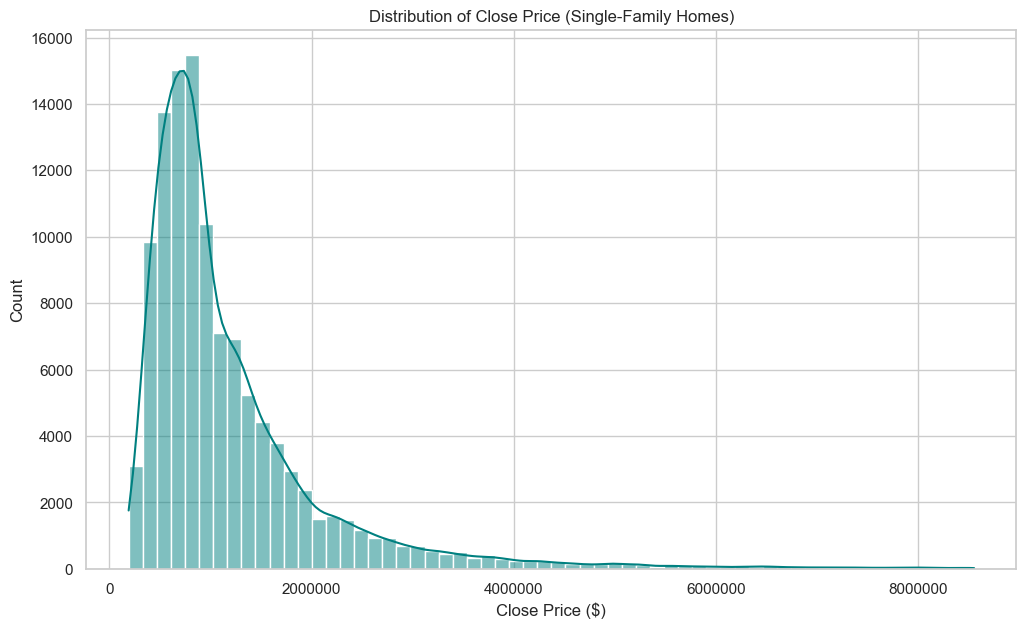


Correlations with ClosePrice (sorted):
ClosePrice               1.000
LivingArea               0.606
BathroomsTotalInteger    0.555
BedroomsTotal            0.342
AssociationFee           0.266
Stories                  0.237
GarageSpaces             0.198
ParkingTotal             0.134
LotSizeArea              0.080
LotSizeSquareFeet        0.074
LotSizeAcres             0.074
Latitude                 0.006
YearBuilt               -0.014
MainLevelBedrooms       -0.058
Longitude               -0.146
Name: ClosePrice, dtype: float64


/var/folders/l2/zp611ys113zd0f_4p1gfzfc80000gn/T/ipykernel_83267/4055448717.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


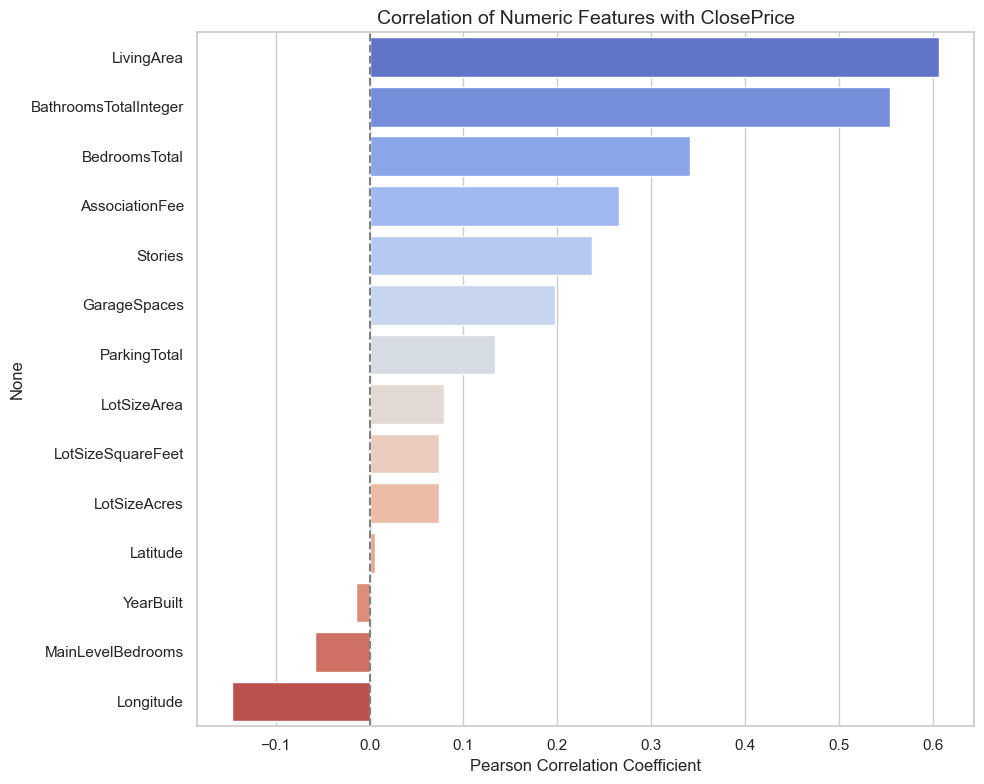

In [81]:
# 3.1 Examine the distribution of the target variable: ClosePrice
# Summary statistics 
print("ClosePrice Summary Statistics:")
print(new_train_df['ClosePrice'].describe())

# Histogram
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)  # wider figure to fit labels

plt.figure()
sns.histplot(data=new_train_df, x='ClosePrice', bins=60, kde=True, color='teal')
plt.title('Distribution of Close Price (Single-Family Homes)')
plt.xlabel('Close Price ($)')
plt.ylabel('Count')
plt.ticklabel_format(style='plain', axis='x') 
plt.show()

# 3.2 Explore the relationships between numeric features and ClosePrice
# Correlation matrix

num_cols = [
    'ClosePrice',           # target
    'LivingArea',
    'BedroomsTotal',
    'BathroomsTotalInteger',
    'LotSizeAcres',
    'LotSizeArea',
    'LotSizeSquareFeet',
    'YearBuilt',
    'ParkingTotal',
    'GarageSpaces',
    'Stories',
    'AssociationFee',
    'Latitude',
    'Longitude',
    'MainLevelBedrooms'
    # You can add others if you think they matter, but most remaining numerics are IDs or empty
]


# Compute correlation matrix
corr_matrix = new_train_df[num_cols].corr()

# Correlations with ClosePrice only – sorted descending
close_corr = corr_matrix['ClosePrice'].sort_values(ascending=False)

print("\nCorrelations with ClosePrice (sorted):")
print(close_corr.round(3))

# Bar plot – strongest associations
plt.figure(figsize=(10, 8))
sns.barplot(
    x=close_corr.values[1:],           # exclude self-correlation
    y=close_corr.index[1:],
    palette='coolwarm'
)
plt.axvline(0, color='gray', linestyle='--')
plt.title('Correlation of Numeric Features with ClosePrice', fontsize=14)
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()


In [82]:
# 3.2 Explore the relationships between non-numeric features (e.g., categorical) and ClosePrice

from scipy import stats

cat_cols = [
    'CountyOrParish', 
    'Levels', 
    'NewConstructionYN',
    'PoolPrivateYN', 
    'ViewYN', 
    'FireplaceYN', 
    'AttachedGarageYN',
    'AssociationFeeFrequency', 
    'Stories', 
    'Flooring',
    'HighSchoolDistrict',
    'MLSAreaMajor',
    'City', 
]


print("Categorical columns being analyzed:", cat_cols)


def kruskal_test_by_category(df, cat_col, target_col='ClosePrice', min_obs_per_group=10):
    """
    Runs Kruskal-Wallis test on ClosePrice grouped by a categorical column.
    Skips groups with too few observations.
    """
    # Drop NaN in the category or target
    df_valid = df.dropna(subset=[cat_col, target_col]).copy()
    
    # Group prices by category
    groups = []
    group_names = []
    
    for name, group in df_valid.groupby(cat_col):
        prices = group[target_col].values
        if len(prices) >= min_obs_per_group:
            groups.append(prices)
            group_names.append(name)
    
    if len(groups) < 2:
        print(f"Not enough valid groups for {cat_col} (need ≥2 groups with ≥{min_obs_per_group} obs each)")
        return None
    
    # Run Kruskal-Wallis
    # All features except AttachedGarageYN show highly significant differences in ClosePrice across categories (p < 0.05 or much lower).  
    stat, p_value = stats.kruskal(*groups)
    
    print(f"\nKruskal-Wallis Test: {cat_col} vs {target_col}")
    print(f"Number of groups tested: {len(groups)}")
    print(f"Groups tested: {', '.join(map(str, group_names[:10]))}{'...' if len(group_names) > 10 else ''}")
    print(f"Statistic: {stat:.3f}")
    print(f"p-value:   {p_value:.4e}")
    
    if p_value < 0.05:
        print("→ Statistically significant differences (p < 0.05)")
    elif p_value < 0.10:
        print("→ Marginally significant differences (p < 0.10)")
    else:
        print("→ No strong evidence of differences (p ≥ 0.10)")
    
    return stat, p_value
    
# Run Kruskal-Wallis on each
for col in cat_cols:
    if col in new_train_df.columns:
        kruskal_test_by_category(new_train_df, col)
    else:
        print(f"Column not found: {col}")


Categorical columns being analyzed: ['CountyOrParish', 'Levels', 'NewConstructionYN', 'PoolPrivateYN', 'ViewYN', 'FireplaceYN', 'AttachedGarageYN', 'AssociationFeeFrequency', 'Stories', 'Flooring', 'HighSchoolDistrict', 'MLSAreaMajor', 'City']

Kruskal-Wallis Test: CountyOrParish vs ClosePrice
Number of groups tested: 47
Groups tested: Alameda, Butte, Calaveras, Contra Costa, El Dorado, Fresno, Glenn, Imperial, Kern, Kings...
Statistic: 50024.515
p-value:   0.0000e+00
→ Statistically significant differences (p < 0.05)

Kruskal-Wallis Test: Levels vs ClosePrice
Number of groups tested: 12
Groups tested: MultiSplit, MultiSplit,One, One, One,MultiSplit, One,ThreeOrMore, One,Two, ThreeOrMore, ThreeOrMore,MultiSplit, Two, Two,MultiSplit...
Statistic: 9302.459
p-value:   0.0000e+00
→ Statistically significant differences (p < 0.05)

Kruskal-Wallis Test: NewConstructionYN vs ClosePrice
Number of groups tested: 2
Groups tested: False, True
Statistic: 679.501
p-value:   8.5779e-150
→ Statistica

## 1.4 Impute Missing values

In [83]:
# 4.1 Impute median (by Zipcodes) for numeric features

In [84]:
# Number of unique ZIP codes
print("Number of unique PostalCode values:", new_train_df['PostalCode'].nunique())

# Distribution of properties per ZIP code
print("\nProperties per PostalCode (sorted descending):")
zip_counts = new_train_df['PostalCode'].value_counts()
print(zip_counts.head(20))   # top 20 most common
print("\n... (total unique ZIPs:", len(zip_counts), ")")
print("\nZIPs with very few properties:")
print(zip_counts.tail(10))   # rarest ZIPs

# Summary stats on counts
# Some zip codes have only 1 or few propertities -> group zip codes by the first 3 digits
print("\nSummary of ZIP code frequencies:")
print(zip_counts.describe().round(0))

# Convert PostalCode to string 
new_train_df['PostalCode'] = new_train_df['PostalCode'].astype(str)

# Extract first 3 digits as ZIP prefix
new_train_df['ZIP_prefix'] = new_train_df['PostalCode'].str[:3]

# Number of unique ZIP prefixes
num_unique_prefixes = new_train_df['ZIP_prefix'].nunique()
print(f"Number of unique ZIP prefixes (first 3 digits): {num_unique_prefixes}")

print("Unique ZIP prefixes and their frequencies (sorted by prefix):")
print(new_train_df['ZIP_prefix'].value_counts().sort_index())


Number of unique PostalCode values: 1977

Properties per PostalCode (sorted descending):
PostalCode
92253    881
92345    708
92584    656
92223    644
92596    608
92592    589
92336    524
92562    511
93536    496
92211    489
92563    488
92308    484
92203    469
92530    459
93065    436
92392    436
93535    435
94513    435
93551    416
92545    414
Name: count, dtype: int64

... (total unique ZIPs: 1977 )

ZIPs with very few properties:
PostalCode
94803-1612    1
95237         1
94133         1
94553-2344    1
94806-1632    1
94533-7787    1
94545-4016    1
94561-00      1
94555-3636    1
95919         1
Name: count, dtype: int64

Summary of ZIP code frequencies:
count    1977.0
mean       58.0
std        94.0
min         1.0
25%         1.0
50%         7.0
75%        86.0
max       881.0
Name: count, dtype: float64
Number of unique ZIP prefixes (first 3 digits): 67
Unique ZIP prefixes and their frequencies (sorted by prefix):
ZIP_prefix
023       1
193       1
202       1
205

In [85]:
# Convert to numeric, invalid become NaN
new_train_df['ZIP_prefix_num'] = pd.to_numeric(new_train_df['ZIP_prefix'], errors='coerce')

# Valid CA ZIP mask
valid_zip_mask = (
    new_train_df['ZIP_prefix_num'].notna() &
    (new_train_df['ZIP_prefix_num'] >= 900) &
    (new_train_df['ZIP_prefix_num'] <= 961)
)

# Apply filter
new_train_df = new_train_df[valid_zip_mask].copy()

# Drop the temporary column
new_train_df = new_train_df.drop(columns=['ZIP_prefix_num'], errors='ignore')


In [86]:
print(new_train_df['ZIP_prefix'].value_counts().sort_index())

ZIP_prefix
900     5025
902     3042
903      134
904      203
905      572
906     2244
907     1763
908     1237
910     1236
911      681
912      502
913     6336
914      967
915      369
916      632
917     6670
918      134
919     1642
920     5759
921     3363
922     6541
923     8166
924     1028
925    10397
926     6092
927     1020
928     4770
930     2869
931      121
932      433
933      655
934     2358
935     2595
936      682
937      276
939     1129
940     1750
941      193
943      212
944      325
945     9059
946     1619
947      570
948      588
949       51
950     2192
951     1816
952      197
953     1555
954      576
955        3
956      259
957       68
958      205
959     1484
960      149
961       22
Name: count, dtype: int64


In [87]:
# Summary table: missing % 
numeric_summary = pd.DataFrame({
    'Column': num_cols,
    'Non-Null Count': [new_train_df[col].notna().sum() for col in num_cols],
    'Missing %': [new_train_df[col].isna().sum() / len(new_train_df) * 100 for col in num_cols]
}).round(2)

print("\nNumerical Summary:")
print(numeric_summary.sort_values('Missing %', ascending=False))


Numerical Summary:
                   Column  Non-Null Count  Missing %
14      MainLevelBedrooms           70660      38.31
11         AssociationFee           81510      28.83
10                Stories          102106      10.85
9            GarageSpaces          110084       3.89
7               YearBuilt          114485       0.04
0              ClosePrice          114536       0.00
1              LivingArea          114536       0.00
2           BedroomsTotal          114536       0.00
3   BathroomsTotalInteger          114536       0.00
4            LotSizeAcres          114536       0.00
5             LotSizeArea          114536       0.00
6       LotSizeSquareFeet          114536       0.00
8            ParkingTotal          114536       0.00
12               Latitude          114536       0.00
13              Longitude          114536       0.00


In [88]:
# List of numeric columns we're imputing
num_cols_to_impute = [
    'MainLevelBedrooms',
    'AssociationFee',
    'Stories',
    'GarageSpaces',
    'YearBuilt'
]

print(new_train_df['ZIP_prefix'].dtype)



object


In [89]:
# Check for each column: how many missing values are in ZIP prefixes with no non-missing data
print("Check for ZIP_prefix median fallback need:")
for col in num_cols_to_impute:
    # ZIP prefixes with at least one non-missing value for this column
    zip_has_data = new_train_df[new_train_df[col].notna()]['ZIP_prefix'].unique()
    
    # Missing values in ZIP prefixes that have NO data for this column
    missing_in_no_data_zips = new_train_df[
        (new_train_df[col].isna()) & 
        (~new_train_df['ZIP_prefix'].isin(zip_has_data))
    ].shape[0]
    
    total_missing = new_train_df[col].isna().sum()
    
    print(f"\n{col}:")
    print(f"  Total missing: {total_missing:,}")
    print(f"  Missing in ZIP prefixes with no data for {col}: {missing_in_no_data_zips:,}")
    print(f"  % of missing that would need global fallback: "
          f"{(missing_in_no_data_zips / total_missing * 100) if total_missing > 0 else 0:.2f}%")

Check for ZIP_prefix median fallback need:

MainLevelBedrooms:
  Total missing: 43,876
  Missing in ZIP prefixes with no data for MainLevelBedrooms: 895
  % of missing that would need global fallback: 2.04%

AssociationFee:
  Total missing: 33,026
  Missing in ZIP prefixes with no data for AssociationFee: 0
  % of missing that would need global fallback: 0.00%

Stories:
  Total missing: 12,430
  Missing in ZIP prefixes with no data for Stories: 0
  % of missing that would need global fallback: 0.00%

GarageSpaces:
  Total missing: 4,452
  Missing in ZIP prefixes with no data for GarageSpaces: 0
  % of missing that would need global fallback: 0.00%

YearBuilt:
  Total missing: 51
  Missing in ZIP prefixes with no data for YearBuilt: 0
  % of missing that would need global fallback: 0.00%


In [90]:
# Compute medians by ZIP_prefix
medians_by_zip = {}
for col in num_cols_to_impute:
    medians_by_zip[col] = new_train_df.groupby('ZIP_prefix')[col].median()

# Global fallback medians (only used when ZIP has no data)
global_medians = {col: new_train_df[col].median() for col in num_cols_to_impute}

# Imputation function
def impute_by_zip(row, col):
    if pd.isna(row[col]):
        zip_median = medians_by_zip[col].get(row['ZIP_prefix'], None)
        if pd.notna(zip_median):
            return zip_median
        return global_medians[col]
    return row[col]

# Apply imputation
for col in num_cols_to_impute:
    new_train_df[col] = new_train_df.apply(lambda row: impute_by_zip(row, col), axis=1)

# Verification
print("\nMissing values after ZIP-prefix median imputation:")
print(new_train_df[num_cols_to_impute].isna().sum())

print("\nUpdated descriptive statistics:")
print(new_train_df[num_cols_to_impute].describe().round(2))


Missing values after ZIP-prefix median imputation:
MainLevelBedrooms    0
AssociationFee       0
Stories              0
GarageSpaces         0
YearBuilt            0
dtype: int64

Updated descriptive statistics:
       MainLevelBedrooms  AssociationFee    Stories  GarageSpaces  YearBuilt
count          114536.00       114536.00  114536.00     114536.00  114536.00
mean                2.29          102.04       1.32          1.98    1975.43
std                 1.76          249.63       0.47          0.89      27.56
min                 0.00            0.00       1.00          0.00    1776.00
25%                 2.00            0.00       1.00          2.00    1955.00
50%                 2.00            0.00       1.00          2.00    1976.00
75%                 3.00          164.00       2.00          2.00    1998.00
max               444.00        14129.00       2.00         40.00    2026.00


In [91]:
# Summary table: missing % and unique count for each
cat_summary = pd.DataFrame({
    'Column': cat_cols,
    'Non-Null Count': [new_train_df[col].notna().sum() for col in cat_cols],
    'Missing %': [new_train_df[col].isna().sum() / len(new_train_df) * 100 for col in cat_cols],
    'Unique Values': [new_train_df[col].nunique() for col in cat_cols]
}).round(2)

print("\nCategorical Summary:")
print(cat_summary.sort_values('Missing %', ascending=False))


Categorical Summary:
                     Column  Non-Null Count  Missing %  Unique Values
7   AssociationFeeFrequency           28855      74.81              4
9                  Flooring           75016      34.50            258
10       HighSchoolDistrict           85281      25.54            409
11             MLSAreaMajor           97588      14.80            998
6          AttachedGarageYN          101894      11.04              2
4                    ViewYN          103651       9.50              2
3             PoolPrivateYN          105393       7.98              2
1                    Levels          105806       7.62             17
2         NewConstructionYN          105824       7.61              2
5               FireplaceYN          114467       0.06              2
12                     City          114490       0.04            914
0            CountyOrParish          114536       0.00             55
8                   Stories          114536       0.00              

In [92]:
cat_cols_to_impute = [
    'AssociationFeeFrequency',
    'Flooring',
    'HighSchoolDistrict',
    'MLSAreaMajor',
    'AttachedGarageYN',
    'ViewYN',
    'PoolPrivateYN',
    'NewConstructionYN',
    'Levels',
    'FireplaceYN',
    'City'
]

In [93]:
# Compute mode (most frequent) per ZIP_prefix for each categorical column
modes_by_zip = {}
for col in cat_cols_to_impute:
    modes_by_zip[col] = new_train_df.groupby('ZIP_prefix')[col].agg(lambda x: x.mode()[0] if not x.mode().empty else pd.NA)

# Global fallback modes
global_modes = {col: new_train_df[col].mode()[0] if not new_train_df[col].mode().empty else pd.NA for col in cat_cols_to_impute}

# Imputation function: ZIP-prefix mode first, global mode fallback
def impute_cat_by_zip(row, col):
    if pd.isna(row[col]):
        zip_mode = modes_by_zip[col].get(row['ZIP_prefix'], None)
        if pd.notna(zip_mode):
            return zip_mode
        return global_modes[col]
    return row[col]

# Apply imputation to each categorical column
for col in cat_cols_to_impute:
    print(f"Imputing {col} using ZIP-prefix mode...")
    new_train_df[col] = new_train_df.apply(lambda row: impute_cat_by_zip(row, col), axis=1)

# Verification
print("\nMissing values after imputation:")
print(new_train_df[cat_cols_to_impute].isna().sum())

print("\nUpdated descriptive statistics:")
print(new_train_df[cat_cols_to_impute].describe().round(2))

Imputing AssociationFeeFrequency using ZIP-prefix mode...
Imputing Flooring using ZIP-prefix mode...
Imputing HighSchoolDistrict using ZIP-prefix mode...
Imputing MLSAreaMajor using ZIP-prefix mode...
Imputing AttachedGarageYN using ZIP-prefix mode...
Imputing ViewYN using ZIP-prefix mode...
Imputing PoolPrivateYN using ZIP-prefix mode...
Imputing NewConstructionYN using ZIP-prefix mode...
Imputing Levels using ZIP-prefix mode...
Imputing FireplaceYN using ZIP-prefix mode...
Imputing City using ZIP-prefix mode...

Missing values after imputation:
AssociationFeeFrequency    0
Flooring                   0
HighSchoolDistrict         0
MLSAreaMajor               0
AttachedGarageYN           0
ViewYN                     0
PoolPrivateYN              0
NewConstructionYN          0
Levels                     0
FireplaceYN                0
City                       0
dtype: int64

Updated descriptive statistics:
       AssociationFeeFrequency     Flooring   HighSchoolDistrict  \
count         

## 1.5 Encoding

In [94]:
categorical_summary = pd.DataFrame({
    'Column': cat_cols,
    'Non-Null Count': [new_train_df[col].notna().sum() for col in cat_cols],
    'Missing %': [new_train_df[col].isna().sum() / len(new_train_df) * 100 for col in cat_cols],
    'Unique Values': [new_train_df[col].nunique() for col in cat_cols]
}).round(2)

print("\nCategorical Summary:")
print(categorical_summary.sort_values('Unique Values', ascending=False))


Categorical Summary:
                     Column  Non-Null Count  Missing %  Unique Values
11             MLSAreaMajor          114536        0.0            998
12                     City          114536        0.0            914
10       HighSchoolDistrict          114536        0.0            409
9                  Flooring          114536        0.0            258
0            CountyOrParish          114536        0.0             55
1                    Levels          114536        0.0             17
7   AssociationFeeFrequency          114536        0.0              4
2         NewConstructionYN          114536        0.0              2
3             PoolPrivateYN          114536        0.0              2
4                    ViewYN          114536        0.0              2
5               FireplaceYN          114536        0.0              2
6          AttachedGarageYN          114536        0.0              2
8                   Stories          114536        0.0              

In [95]:
# I don't think we need to use MLSAreaMajor, CountyOrParish, or City in our model as we already have Zip codes
# print(new_train_df['MLSAreaMajor'].value_counts(dropna=False)) 
# print(new_train_df['CountyOrParish'].value_counts(dropna=False)) # We might not need to use this in our model as we already have Zip code and City
# print(new_train_df['City'].value_counts(dropna=False))

In [96]:
# For these high-cardinality features (HighSchoolDistrict, Flooring), use target encoding (also called mean encoding)
# -> reduces each category to a single numeric value (e.g., mean ClosePrice in that category)
# -> adds 1 column per feature
print(new_train_df['HighSchoolDistrict'].value_counts(dropna=False))
print(new_train_df['Flooring'].value_counts(dropna=False))

HighSchoolDistrict
Los Angeles Unified         12773
Other                        7861
San Ramon Valley             6649
Beaumont                     4209
San Diego Unified            3040
                            ...  
Caliente Union                  1
Del Norte County Unified        1
Jefferson Union                 1
Bret Harte Union                1
Belmont-Redwood Shores          1
Name: count, Length: 409, dtype: int64
Flooring
Carpet,Tile                                  30432
Wood                                         18708
Laminate                                      8422
Tile,Wood                                     7825
Carpet,Tile,Wood                              5434
                                             ...  
Concrete,SeeRemarks,Stone,Vinyl                  1
Carpet,Concrete,Laminate,SeeRemarks,Stone        1
Laminate,SeeRemarks,Stone,Tile,Wood              1
Carpet,Concrete,Laminate,Stone,Tile,Wood         1
Bamboo,Stone,Tile,Wood                           

In [97]:
# Target encoding function (fits on train)
def target_encode_fit(df, cat_col, target_col='ClosePrice'):
    means = df.groupby(cat_col)[target_col].mean()
    global_mean = df[target_col].mean()
    encoded_col = f'{cat_col}_target_mean'
    df[encoded_col] = df[cat_col].map(means).fillna(global_mean)
    return df, means, global_mean

# Apply and save the mappings
new_train_df, highschool_means, highschool_global = target_encode_fit(new_train_df, 'HighSchoolDistrict')

In [98]:
joblib.dump(highschool_means, 'highschool_target_means.pkl')   
joblib.dump(highschool_global, 'highschool_global_mean.pkl')  

['highschool_global_mean.pkl']

In [99]:
# Apply and save the mappings
new_train_df, flooring_means, flooring_global = target_encode_fit(new_train_df, 'Flooring')

In [100]:
joblib.dump(flooring_means, 'flooring_target_means.pkl')
joblib.dump(flooring_global, 'flooring_global_mean.pkl')

['flooring_global_mean.pkl']

In [101]:
print("Target-encoded columns added on train:")
print(new_train_df[['HighSchoolDistrict', 'HighSchoolDistrict_target_mean',
                'Flooring', 'Flooring_target_mean']].head(10))

Target-encoded columns added on train:
             HighSchoolDistrict  HighSchoolDistrict_target_mean  \
5              Redlands Unified                    7.058607e+05   
6     Saddleback Valley Unified                    1.514307e+06   
8   Santa Monica-Malibu Unified                    4.037796e+06   
9   Huntington Beach Union High                    1.699944e+06   
10             Pasadena Unified                    1.970324e+06   
12               Orange Unified                    1.454943e+06   
13               Tustin Unified                    1.962938e+06   
18          Los Angeles Unified                    1.549049e+06   
21               Irvine Unified                    2.388591e+06   
22         Newport Mesa Unified                    3.404106e+06   

             Flooring  Flooring_target_mean  
5         Carpet,Tile          8.740094e+05  
6   Carpet,Vinyl,Wood          1.099181e+06  
8     Stone,Tile,Wood          2.776815e+06  
9               Vinyl          9.756759

In [102]:
# recode Levels
print(new_train_df['Levels'].value_counts(dropna=False)) 

# make levels variable more simple
def recode_levels_final(x):
    if pd.isna(x):
        return x
    if "ThreeOrMore" in x:
        return "ThreeOrMore"
    elif "Two" in x:
        return "Two"
    elif "One" in x:
        return "One"
    elif "MultiSplit" in x:
        return "MultiSplit"
    else:
        return "Other"

new_train_df["Levels_final"] = new_train_df["Levels"].apply(recode_levels_final)

new_train_df["Levels_final"].value_counts()

Levels
One                               74338
Two                               35707
ThreeOrMore                        2043
MultiSplit                         1593
One,Two                             256
Two,One                             195
Two,MultiSplit                      179
One,MultiSplit                       67
ThreeOrMore,MultiSplit               64
Two,ThreeOrMore                      36
MultiSplit,One                       21
One,ThreeOrMore                      21
One,Two,MultiSplit                    5
One,Two,ThreeOrMore                   4
Two,ThreeOrMore,MultiSplit            3
ThreeOrMore,One                       2
One,Two,ThreeOrMore,MultiSplit        2
Name: count, dtype: int64


Levels_final
One            74426
Two            36342
ThreeOrMore     2175
MultiSplit      1593
Name: count, dtype: int64

In [103]:
# For low-cardinality features (Levels_final, AssociationFeeFrequency, Stories)
# use one-hot encoding

# For NewConstructionYN, PoolPrivateYN, ViewYN, FireplaceYN, AttachedGarageYN, already binary, no encoding needed

low_card_cols = [
    'Levels_final', 
    'AssociationFeeFrequency',
    'Stories'
]

# Recode from float to object
new_train_df['Stories'] = new_train_df['Stories'].astype(str).replace('nan', 'Missing')
print("Converted Stories to object dtype. New dtype:", new_train_df['Stories'].dtype)
print("Unique Stories values now:", new_train_df['Stories'].unique())

# One-hot encode
dummies = pd.get_dummies(
    new_train_df[low_card_cols],
    prefix=low_card_cols,
    drop_first=True,
    dtype=int
)

# Add to DataFrame
new_train_df = pd.concat([new_train_df.drop(columns=low_card_cols), dummies], axis=1)

print(f"Added {dummies.shape[1]} new binary columns")
print("New shape:", new_train_df.shape)
print("\nNew one-hot columns from Stories (example):")
print([c for c in dummies.columns if 'Stories' in c])


Converted Stories to object dtype. New dtype: object
Unique Stories values now: ['1.0' '2.0']
Added 7 new binary columns
New shape: (114536, 66)

New one-hot columns from Stories (example):
['Stories_2.0']


## 1.6 Scaling

In [104]:
# Normalize/scale numerical features
# Apply StandardScaler: Subtracts mean, divides by standard deviation
# Narrow it down to LivingArea, LotSizeSquareFeet, AssociationFee, which spans several orders of magnitudes

num_cols_to_scale = [           
    'LivingArea',
    'LotSizeSquareFeet',
    'AssociationFee'
]
    
print(new_train_df[num_cols_to_scale].describe().round(2))

# Choose StandardScaler: subtracts mean of data and divides by sd 
# -> reduce the effect of outliers/extreme values
scaler = StandardScaler()
scaled_values = scaler.fit_transform(new_train_df[num_cols_to_scale])

# Create new scaled columns
scaled_df = pd.DataFrame(
    scaled_values,
    columns=[f"{col}_std" for col in num_cols_to_scale],
    index=new_train_df.index
)

# Add to main DataFrame
new_train_df = pd.concat([new_train_df, scaled_df], axis=1)

print("\nfirst 5 rows:")
print(new_train_df[[f"{col}_std" for col in num_cols_to_scale]].head())

print("\nScaled columns summary:")
print(new_train_df[[f"{col}_std" for col in num_cols_to_scale]].describe().round(2))



       LivingArea  LotSizeSquareFeet  AssociationFee
count   114536.00          114536.00       114536.00
mean      2015.90           12663.85          102.04
std        932.15           21919.46          249.63
min          2.00               2.20            0.00
25%       1385.00            5663.00            0.00
50%       1807.00            7217.00            0.00
75%       2414.00           10087.00          164.00
max      14168.00          217800.00        14129.00

first 5 rows:
    LivingArea_std  LotSizeSquareFeet_std  AssociationFee_std
5         0.444248               0.086506           -0.408762
6        -0.218738              -0.427195            0.612745
8         1.230604               0.653173           -0.408762
9        -0.177972              -0.406711            0.440491
10        5.553957               1.683769           -0.408762

Scaled columns summary:
       LivingArea_std  LotSizeSquareFeet_std  AssociationFee_std
count       114536.00              114536.00  

In [105]:
joblib.dump(scaler, 'train_scaler.pkl')
print("Scaler saved to 'train_scaler.pkl'")

Scaler saved to 'train_scaler.pkl'


## 1.7 Feature Engineering

In [106]:
# Capture local market trend
# i.e., recent "comps" in the same neighborhood can be a strong predictor

# Convert to date time
new_train_df['CloseDate'] = pd.to_datetime(new_train_df['CloseDate'])

# Create monthly period
new_train_df['CloseMonth'] = new_train_df['CloseDate'].dt.to_period('M')

print(new_train_df['CloseMonth'].value_counts())

CloseMonth
2025-07    11632
2025-10    11463
2025-04    11352
2025-05    11286
2025-06    11197
2025-09    10979
2025-08    10919
2025-03    10204
2025-11     9302
2025-02     8443
2025-01     7759
Freq: M, Name: count, dtype: int64


In [107]:
# Compute median price per ZIP_prefix per month
monthly_medians = new_train_df.groupby(['ZIP_prefix', 'CloseMonth'])['ClosePrice'].median().reset_index()
monthly_medians = monthly_medians.sort_values(['ZIP_prefix', 'CloseMonth'])
print(monthly_medians)

    ZIP_prefix CloseMonth  ClosePrice
0          900    2025-01   1215000.0
1          900    2025-02   1450000.0
2          900    2025-03   1377000.0
3          900    2025-04   1340000.0
4          900    2025-05   1307500.0
..         ...        ...         ...
612        961    2025-07    912500.0
613        961    2025-08    737500.0
614        961    2025-09    400000.0
615        961    2025-10   1850000.0
616        961    2025-11    399000.0

[617 rows x 3 columns]


In [108]:
# Compute month-over-month growth rate
monthly_medians['prev_median'] = monthly_medians.groupby('ZIP_prefix')['ClosePrice'].shift(1)
monthly_medians['mom_growth'] = (monthly_medians['ClosePrice'] - monthly_medians['prev_median']) / monthly_medians['prev_median']
print(monthly_medians['mom_growth'])

0           NaN
1      0.193416
2     -0.050345
3     -0.026870
4     -0.024254
         ...   
612   -0.768987
613   -0.191781
614   -0.457627
615    3.625000
616   -0.784324
Name: mom_growth, Length: 617, dtype: float64


In [109]:
# Backfill the first month's (January) growth rate with the next available MoM (July)
monthly_medians['mom_growth'] = monthly_medians.groupby('ZIP_prefix')['mom_growth'].bfill()

print(monthly_medians['mom_growth'])

# no remaining NaN values
print(monthly_medians['mom_growth'].isna().sum())

0      0.193416
1      0.193416
2     -0.050345
3     -0.026870
4     -0.024254
         ...   
612   -0.768987
613   -0.191781
614   -0.457627
615    3.625000
616   -0.784324
Name: mom_growth, Length: 617, dtype: float64
0


In [110]:
# Now aggregate: mean MoM growth per ZIP_prefix
zip_growth_rate = monthly_medians.groupby('ZIP_prefix')['mom_growth'].mean().reset_index()
zip_growth_rate = zip_growth_rate.rename(columns={'mom_growth': 'zip_growth_rate'})
print(zip_growth_rate )

   ZIP_prefix  zip_growth_rate
0         900         0.033488
1         902         0.036948
2         903        -0.000913
3         904         0.011324
4         905         0.013096
5         906         0.006703
6         907         0.008855
7         908         0.011795
8         910         0.000975
9         911         0.004140
10        912         0.002379
11        913        -0.001643
12        914         0.007261
13        915         0.021340
14        916         0.025898
15        917        -0.000039
16        918         0.014040
17        919         0.005059
18        920         0.002243
19        921         0.016865
20        922         0.000278
21        923        -0.006741
22        924         0.004400
23        925         0.001748
24        926         0.001234
25        927         0.003260
26        928         0.004263
27        930         0.011691
28        931        -0.068221
29        932        -0.001104
30        933         0.021854
31      

In [111]:
# Merge back to train
new_train_df = new_train_df.merge(zip_growth_rate, on='ZIP_prefix', how='left')

print(new_train_df['zip_growth_rate'].head(10))

# no NaN values
print(new_train_df['zip_growth_rate'].isna().sum())

print(new_train_df['zip_growth_rate'].describe().round(4))

0   -0.006741
1    0.001234
2    0.011324
3    0.003260
4    0.004140
5    0.004263
6    0.003260
7   -0.001643
8    0.001234
9    0.001234
Name: zip_growth_rate, dtype: float64
0
count    114536.0000
mean          0.0092
std           0.0258
min          -0.0682
25%           0.0003
50%           0.0022
75%           0.0165
max           1.5851
Name: zip_growth_rate, dtype: float64


In [112]:
# Create distance to coast
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

# Define several major coastal points (lat, lon)
coastal_points = [
    (34.0100, -118.4960),  # Santa Monica Beach (LA area)
    (37.8199, -122.4786),  # Pacific coast near Golden Gate / SF
    (32.7157, -117.1611),  # San Diego harbor/coast
    (36.6002, -121.8947),  # Monterey Bay coast
    (40.8021, -124.1637)   # Northern CA coast proxy
]


# Compute min distance to any coast for each property
def min_distance_to_coast(row):
    distances = [haversine(row['Latitude'], row['Longitude'], lat, lon) for lat, lon in coastal_points]
    return min(distances)

new_train_df['dist_to_coast_km'] = new_train_df.apply(min_distance_to_coast, axis=1)

print(new_train_df['dist_to_coast_km'].describe().round(2))

count    114536.00
mean         72.80
std          48.67
min           0.00
25%          34.13
50%          62.22
75%         105.81
max         335.42
Name: dist_to_coast_km, dtype: float64


In [113]:
# Define reference year
REFERENCE_YEAR = 2026

# Create Age column
new_train_df['Age'] = REFERENCE_YEAR - new_train_df['YearBuilt']

In [114]:
# One hot encode ZIP_prefix
zip_dummies_train = pd.get_dummies(
    new_train_df['ZIP_prefix'],
    prefix='ZIP_prefix',
    drop_first=True,
    dtype=int
)

# Add to train
new_train_df = pd.concat([new_train_df.drop(columns=['ZIP_prefix']), zip_dummies_train], axis=1)

print(f"Added {zip_dummies_train.shape[1]} ZIP_prefix dummy columns to train")
print("Train shape after:", new_train_df.shape)


Added 56 ZIP_prefix dummy columns to train
Train shape after: (114536, 128)


## 1.8 Train Set Cleaning Complete

In [115]:
# Last step of cleaning: drop irrelevant columns
cols_to_drop = [
    'ListAgentFirstName',
    'ListAgentLastName',
    'ListOfficeName',
    'BuyerOfficeName',
    'CoListOfficeName',
    'ListAgentFullName',
    'CoListAgentFirstName',
    'CoListAgentLastName',
    'BuyerAgentMlsId',
    'BuyerAgentFirstName',
    'BuyerAgentLastName',
    'ContractStatusChangeDate',
    'PurchaseContractDate',
    'ListingContractDate',
    'ListAgentAOR',
    'BuyerAgentAOR',
    'ListAgentEmail',
    'UnparsedAddress',
    'SubdivisionName',
    'BuyerOfficeAOR',
    'StreetNumberNumeric',
    'CloseMonth'
]

# Save CLEAN data
new_train_df_clean = new_train_df.drop(columns=cols_to_drop).copy()

new_train_df_clean.info()

new_train_df_clean.to_csv('new_train_df_clean.csv', index=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114536 entries, 0 to 114535
Columns: 106 entries, Flooring to ZIP_prefix_961
dtypes: bool(5), datetime64[ns](1), float64(23), int64(65), object(12)
memory usage: 88.8+ MB


# 2. Test Set Preprocessing

## 2.1 Data Cleaning

In [116]:
# December 2025 as the test set
new_test_df = pd.read_csv('/Users/yanmingkuang/Desktop/IDX/CRMLSSold202512.csv')
print("Dataset shape:", new_test_df.shape)


Dataset shape: (20538, 78)


In [117]:
# 8.1 Restrict to single-family residential homes
# Keep backup before filtering
test_raw = new_test_df.copy()

# Apply the filter
new_test_df = new_test_df[
    (new_test_df['PropertyType'] == 'Residential') & 
    (new_test_df['PropertySubType'] == 'SingleFamilyResidence')
].copy()

print(f"Filtered to single-family: {new_test_df.shape[0]:,} rows")


# 8.2 Remove top 0.5% and bottom 0.5% of ClosePrice to exclude erroneous / non-economic transactions

lower_threshold = new_test_df['ClosePrice'].quantile(0.005)   # bottom 0.5%
upper_threshold = new_test_df['ClosePrice'].quantile(0.995)   # top 0.5%

print(f"\nOutlier removal thresholds (ClosePrice):")
print(f"  Lower (0.5th percentile): ${lower_threshold:,.0f}")
print(f"  Upper (99.5th percentile): ${upper_threshold:,.0f}")

rows_before = len(new_test_df)
low_outliers  = new_test_df['ClosePrice'] < lower_threshold
high_outliers = new_test_df['ClosePrice'] > upper_threshold

print(f"Rows removed (bottom 0.5%): {low_outliers.sum():,}")
print(f"Rows removed (top 0.5%):    {high_outliers.sum():,}")
print(f"Total rows removed:         {low_outliers.sum() + high_outliers.sum():,}")
print(f"Percentage removed:         {((low_outliers.sum() + high_outliers.sum()) / rows_before) * 100:.3f}%")

new_test_df = new_test_df[
    (new_test_df['ClosePrice'] >= lower_threshold) & 
    (new_test_df['ClosePrice'] <= upper_threshold)
].copy()


# 8.3 Exclude `ListPrice` , `OriginalListPrice`, 'DaysOnMarket'
columns_to_drop = ['ListPrice', 'OriginalListPrice','DaysOnMarket']
new_test_df = new_test_df.drop(columns=columns_to_drop, errors='ignore')


# 8.4 Remove rows where LivingArea is <=0
print("Rows with LivingArea == 0:", (new_test_df['LivingArea'] <= 0).sum())
new_test_df = new_test_df[new_test_df['LivingArea'] > 0].copy()


# 8.5 Remove rows where Latitude or Longitude is missing or invalid

print("\nInvalid Latitude (outside CA range or 0/NaN):")
print(new_test_df[~new_test_df['Latitude'].between(32.5, 42.0)]['Latitude'].value_counts(dropna=False))

print("\nInvalid Longitude (outside CA range or 0/NaN):")
print(new_test_df[~new_test_df['Longitude'].between(-124.5, -114.0)]['Longitude'].value_counts(dropna=False))

lat_min, lat_max = 32.5, 42.0
lon_min, lon_max = -124.5, -114.0

valid_location = (
    new_test_df['Latitude'].notna() &
    new_test_df['Longitude'].notna() &
    new_test_df['Latitude'].between(lat_min, lat_max) &
    new_test_df['Longitude'].between(lon_min, lon_max)
)

new_test_df = new_test_df[valid_location].copy()

# 8.6 remove illogical/impossible values
logical_values = (
    (new_test_df['BedroomsTotal'] > 0) &
    (new_test_df['BathroomsTotalInteger'] > 0) &
    (new_test_df['LotSizeAcres'] > 0) &
    (new_test_df['LotSizeArea'] > 0) &
    (new_test_df['LotSizeSquareFeet'] > 0) &
    (new_test_df['ParkingTotal'] >= 0) &  # >= 0 to allow 0, only drop negative
    (new_test_df['LotSizeSquareFeet'] <= 217800) & #realistic max (e.g., 5 acres = 217,800 sq ft)
    (new_test_df['ParkingTotal'] <= 50) &
    (new_test_df['GarageSpaces'].isna() | new_test_df['GarageSpaces'] <= 100) # keep the missing rows
)


# Apply the filter
new_test_df = new_test_df[logical_values].copy()

print("\nUpdated min values after removal:")
print("BedroomsTotal min:      ", new_test_df['BedroomsTotal'].min())
print("BathroomsTotalInteger min:", new_test_df['BathroomsTotalInteger'].min())
print("LotSizeAcres min:       ", new_test_df['LotSizeAcres'].min())
print("LotSizeArea min:        ", new_test_df['LotSizeArea'].min())
print("LotSizeSquareFeet min:  ", new_test_df['LotSizeSquareFeet'].min())
print("ParkingTotal min:       ", new_test_df['ParkingTotal'].min())
print("LotSizeSquareFeet max:  ", new_test_df['LotSizeSquareFeet'].max())
print("ParkingTotal max:       ", new_test_df['ParkingTotal'].max())
print("GarageSpaces max:       ", new_test_df['GarageSpaces'].max())

# 8.7 remove duplicate rows with the same ListingIDs and other features
duplicates = new_test_df[new_test_df['ListingId'].duplicated(keep=False)].sort_values('ListingId')

print(f"Found {len(duplicates):,} duplicate rows (all occurrences)")
print("\nSample duplicate rows:")
print(duplicates[['ListingId', 'ClosePrice', 'CloseDate', 'City', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger']].head(10))

new_test_df = new_test_df.drop_duplicates(subset='ListingId', keep='first').copy()


# 8.8 remove columns with >80% missing
missing_pct = (new_test_df.isna().mean() * 100).sort_values(ascending=False).round(2)

missing_cols_to_drop = missing_pct[missing_pct > 80].index.tolist()

# show only columns with missing values
print("\nFeatures with missing values (>0%):")
print(missing_pct[missing_pct > 0])

new_test_df = new_test_df.drop(columns=missing_cols_to_drop)

# 8.9 log transform ClosePrice
print(new_test_df["ClosePrice"].isna().sum())
print((new_test_df["ClosePrice"]<=0).sum())
new_test_df["log_ClosePrice"] = np.log(new_test_df["ClosePrice"])

# After all cleaning
print(f"\nTotal rows removed during cleaning: "
      f"{len(test_raw) - len(new_test_df):,} "
      f"({(len(test_raw) - len(new_test_df)) / len(test_raw) * 100:.1f}% of original)")

sorted_cols = sorted(new_test_df.columns)

new_test_df[sorted_cols].info()



Filtered to single-family: 10,455 rows

Outlier removal thresholds (ClosePrice):
  Lower (0.5th percentile): $179,000
  Upper (99.5th percentile): $8,586,500
Rows removed (bottom 0.5%): 52
Rows removed (top 0.5%):    53
Total rows removed:         105
Percentage removed:         1.004%
Rows with LivingArea == 0: 3

Invalid Latitude (outside CA range or 0/NaN):
Latitude
0.000000     3
NaN          2
43.784440    1
31.786721    1
31.853002    1
Name: count, dtype: int64

Invalid Longitude (outside CA range or 0/NaN):
Longitude
 0.000000     3
 NaN          2
-88.787868    1
Name: count, dtype: int64

Updated min values after removal:
BedroomsTotal min:       1.0
BathroomsTotalInteger min: 1.0
LotSizeAcres min:        0.0002
LotSizeArea min:         0.04
LotSizeSquareFeet min:   6.72
ParkingTotal min:        0.0
LotSizeSquareFeet max:   217800.0
ParkingTotal max:        50.0
GarageSpaces max:        20.0
Found 0 duplicate rows (all occurrences)

Sample duplicate rows:
Empty DataFrame
Colu

## 2.2 Impute Missing Values

In [118]:
# Extract first 3 digits as ZIP prefix
new_test_df['ZIP_prefix'] = new_test_df['PostalCode'].str[:3]

# Number of unique ZIP prefixes
num_unique_prefixes = new_test_df['ZIP_prefix'].nunique()
print(f"Number of unique ZIP prefixes (first 3 digits): {num_unique_prefixes}")

print("Unique ZIP prefixes and their frequencies (sorted by prefix):")
print(new_test_df['ZIP_prefix'].value_counts().sort_index())

# Convert to numeric, invalid become NaN
new_test_df['ZIP_prefix_num'] = pd.to_numeric(new_test_df['ZIP_prefix'], errors='coerce')

# Valid CA ZIP mask
valid_zip_mask = (
    new_test_df['ZIP_prefix_num'].notna() &
    (new_test_df['ZIP_prefix_num'] >= 900) &
    (new_test_df['ZIP_prefix_num'] <= 961) &
    (new_test_df['ZIP_prefix_num'] != 929)
)

# Apply filter
new_test_df = new_test_df[valid_zip_mask].copy()

# Drop the temporary column
new_test_df = new_test_df.drop(columns=['ZIP_prefix_num'], errors='ignore')


Number of unique ZIP prefixes (first 3 digits): 57
Unique ZIP prefixes and their frequencies (sorted by prefix):
ZIP_prefix
900    437
902    266
903     19
904     15
905     41
906    215
907    154
908    120
910    103
911     66
912     52
913    604
914     92
915     25
916     56
917    584
918      9
919    135
920    478
921    294
922    603
923    776
924    101
925    925
926    513
927     92
928    407
929      1
930    247
931      6
932     45
933     62
934    224
935    226
936     55
937     26
939    105
940    133
941     19
943     10
944     23
945    693
946    134
947     45
948     40
949      4
950    160
951    115
952     15
953    134
954     72
956     21
957      7
958     17
959    152
960     16
961      1
Name: count, dtype: int64


In [119]:
# For numerical features: apply the same imputation function using train-computed medians
for col in num_cols_to_impute:
    print(f"Imputing {col} on test set using train ZIP-prefix medians...")
    new_test_df[col] = new_test_df.apply(lambda row: impute_by_zip(row, col), axis=1)

# Verification
print("\nMissing values in test after imputation:")
print(new_test_df[num_cols_to_impute].isna().sum())

print("\nTest set descriptive statistics after imputation:")
print(new_test_df[num_cols_to_impute].describe().round(2))

Imputing MainLevelBedrooms on test set using train ZIP-prefix medians...
Imputing AssociationFee on test set using train ZIP-prefix medians...
Imputing Stories on test set using train ZIP-prefix medians...
Imputing GarageSpaces on test set using train ZIP-prefix medians...
Imputing YearBuilt on test set using train ZIP-prefix medians...

Missing values in test after imputation:
MainLevelBedrooms    0
AssociationFee       0
Stories              0
GarageSpaces         0
YearBuilt            0
dtype: int64

Test set descriptive statistics after imputation:
       MainLevelBedrooms  AssociationFee  Stories  GarageSpaces  YearBuilt
count            9989.00         9989.00  9989.00       9989.00    9989.00
mean                2.32           98.70     1.31          1.97    1975.41
std                 1.25          228.92     0.46          0.89      27.84
min                 0.00            0.00     1.00          0.00    1876.00
25%                 2.00            0.00     1.00          2.00  

In [120]:
# For categorical features: Apply the same imputation function using train-computed modes
for col in cat_cols_to_impute:
    print(f"Imputing {col} on test set using train ZIP-prefix modes...")
    new_test_df[col] = new_test_df.apply(lambda row: impute_cat_by_zip(row, col), axis=1)

# Verification
print("\nMissing values in test after imputation:")
print(new_test_df[cat_cols_to_impute].isna().sum())

print("\nTest set descriptive statistics after imputation:")
print(new_test_df[cat_cols_to_impute].describe().round(2))

Imputing AssociationFeeFrequency on test set using train ZIP-prefix modes...
Imputing Flooring on test set using train ZIP-prefix modes...
Imputing HighSchoolDistrict on test set using train ZIP-prefix modes...
Imputing MLSAreaMajor on test set using train ZIP-prefix modes...
Imputing AttachedGarageYN on test set using train ZIP-prefix modes...
Imputing ViewYN on test set using train ZIP-prefix modes...
Imputing PoolPrivateYN on test set using train ZIP-prefix modes...
Imputing NewConstructionYN on test set using train ZIP-prefix modes...
Imputing Levels on test set using train ZIP-prefix modes...
Imputing FireplaceYN on test set using train ZIP-prefix modes...
Imputing City on test set using train ZIP-prefix modes...

Missing values in test after imputation:
AssociationFeeFrequency    0
Flooring                   0
HighSchoolDistrict         0
MLSAreaMajor               0
AttachedGarageYN           0
ViewYN                     0
PoolPrivateYN              0
NewConstructionYN          

## 2.3 Encoding

In [121]:
categorical_summary_test = pd.DataFrame({
    'Column': cat_cols,
    'Non-Null Count': [new_test_df[col].notna().sum() for col in cat_cols],
    'Missing %': [new_test_df[col].isna().sum() / len(new_test_df) * 100 for col in cat_cols],
    'Unique Values': [new_test_df[col].nunique() for col in cat_cols]
}).round(2)

print("\nCategorical Summary:")
print(categorical_summary_test.sort_values('Unique Values', ascending=False))


Categorical Summary:
                     Column  Non-Null Count  Missing %  Unique Values
11             MLSAreaMajor            9989        0.0            781
12                     City            9989        0.0            625
10       HighSchoolDistrict            9989        0.0            319
9                  Flooring            9989        0.0            132
0            CountyOrParish            9989        0.0             47
1                    Levels            9989        0.0             13
7   AssociationFeeFrequency            9989        0.0              4
2         NewConstructionYN            9989        0.0              2
3             PoolPrivateYN            9989        0.0              2
4                    ViewYN            9989        0.0              2
5               FireplaceYN            9989        0.0              2
6          AttachedGarageYN            9989        0.0              2
8                   Stories            9989        0.0              

In [122]:
# Reuse the mappings computed from train
# (highschool_means, highschool_global, flooring_means, flooring_global)

# Apply mapping to test (lookup only — no groupby, no new means)
new_test_df['HighSchoolDistrict_target_mean'] = new_test_df['HighSchoolDistrict'].map(highschool_means).fillna(highschool_global)
new_test_df['Flooring_target_mean'] = new_test_df['Flooring'].map(flooring_means).fillna(flooring_global)

print("Target-encoded columns added on test (using train mappings):")
print(new_test_df[['HighSchoolDistrict', 'HighSchoolDistrict_target_mean',
               'Flooring', 'Flooring_target_mean']].head(10))

print("\nMissing encoded values in test (should be very few):")
print(new_test_df[['HighSchoolDistrict_target_mean', 'Flooring_target_mean']].isna().sum())

Target-encoded columns added on test (using train mappings):
       HighSchoolDistrict  HighSchoolDistrict_target_mean            Flooring  \
0        San Ramon Valley                    1.263100e+06    Carpet,Tile,Wood   
2     Los Angeles Unified                    1.549049e+06         Carpet,Wood   
3                   Other                    1.711513e+06           Tile,Wood   
7        San Jose Unified                    1.918006e+06           Tile,Wood   
9                   Other                    1.711513e+06           Tile,Wood   
10     Capistrano Unified                    1.996255e+06          Vinyl,Wood   
11           Mount Diablo                    1.099371e+06  Laminate,Tile,Wood   
13       Temecula Unified                    8.416601e+05    Carpet,Tile,Wood   
14  San Francisco Unified                    1.510826e+06          SeeRemarks   
16   Laguna Beach Unified                    3.361526e+06         Carpet,Wood   

    Flooring_target_mean  
0           1.721745

In [123]:
# recode Levels
print(new_test_df['Levels'].value_counts(dropna=False)) 

# make levels variable more simple
def recode_levels_final(x):
    if pd.isna(x):
        return x
    if "ThreeOrMore" in x:
        return "ThreeOrMore"
    elif "Two" in x:
        return "Two"
    elif "One" in x:
        return "One"
    elif "MultiSplit" in x:
        return "MultiSplit"
    else:
        return "Other"

new_test_df["Levels_final"] = new_test_df["Levels"].apply(recode_levels_final)

new_test_df["Levels_final"].value_counts()

Levels
One                       6507
Two                       3066
ThreeOrMore                193
MultiSplit                 133
Two,One                     43
One,Two                     20
Two,MultiSplit              11
ThreeOrMore,MultiSplit       6
One,MultiSplit               3
MultiSplit,One               2
One,ThreeOrMore              2
ThreeOrMore,One              2
Two,ThreeOrMore              1
Name: count, dtype: int64


Levels_final
One            6512
Two            3140
ThreeOrMore     204
MultiSplit      133
Name: count, dtype: int64

In [124]:
# For low-cardinality features (Levels_final, AssociationFeeFrequency, Stories)
# use one-hot encoding

# For NewConstructionYN, PoolPrivateYN, ViewYN, FireplaceYN, AttachedGarageYN, already binary, no encoding needed

low_card_cols = [
    'Levels_final', 
    'AssociationFeeFrequency',
    'Stories'
]

# Recode from float to object
new_test_df['Stories'] = new_test_df['Stories'].astype(str).replace('nan', 'Missing')
print("Converted Stories to object dtype. New dtype:", new_test_df['Stories'].dtype)
print("Unique Stories values now:", new_test_df['Stories'].unique())

# One-hot encode
dummies = pd.get_dummies(
    new_test_df[low_card_cols],
    prefix=low_card_cols,
    drop_first=True,
    dtype=int
)

# Add to DataFrame
new_test_df = pd.concat([new_test_df.drop(columns=low_card_cols), dummies], axis=1)

print(f"Added {dummies.shape[1]} new binary columns")
print("New shape:", new_test_df.shape)
print("\nNew one-hot columns from Stories (example):")
print([c for c in dummies.columns if 'Stories' in c])


Converted Stories to object dtype. New dtype: object
Unique Stories values now: ['1.0' '2.0']
Added 7 new binary columns
New shape: (9989, 66)

New one-hot columns from Stories (example):
['Stories_2.0']


## 2.4 Scaling

In [125]:
# Apply transform only (using train's mean & std)
new_test_df[[f"{col}_std" for col in num_cols_to_scale]] = scaler.transform(new_test_df[num_cols_to_scale])

print("\nTest set scaled columns preview:")
print(new_test_df[[f"{col}_std" for col in num_cols_to_scale]].head().round(3))

print("\nTest scaled columns summary:")
print(new_test_df[[f"{col}_std" for col in num_cols_to_scale]].describe().round(3))


Test set scaled columns preview:
   LivingArea_std  LotSizeSquareFeet_std  AssociationFee_std
0           0.031                 -0.118               3.497
2           1.109                  1.007              -0.409
3          -0.453                 -0.277               0.272
7           0.734                 -0.201               0.272
9           1.000                 -0.157               0.272

Test scaled columns summary:
       LivingArea_std  LotSizeSquareFeet_std  AssociationFee_std
count        9989.000               9989.000            9989.000
mean           -0.014                  0.022              -0.013
std             1.000                  1.060               0.917
min            -1.769                 -0.577              -0.409
25%            -0.706                 -0.319              -0.409
50%            -0.232                 -0.249              -0.409
75%             0.421                 -0.118               0.248
max             8.044                  9.359      

## 2.5 Feature Engineering

In [126]:
# Merge zip_growth_rate back to train
new_test_df = new_test_df.merge(zip_growth_rate, on='ZIP_prefix', how='left')

print(new_test_df['zip_growth_rate'].head(10))

# no NaN values
print(new_test_df['zip_growth_rate'].isna().sum())

print(new_test_df['zip_growth_rate'].describe().round(4))

0    0.031842
1   -0.001643
2    0.014370
3    0.014370
4    0.014370
5    0.001234
6    0.031842
7    0.001748
8   -0.002848
9    0.001234
Name: zip_growth_rate, dtype: float64
0
count    9989.0000
mean        0.0086
std         0.0207
min        -0.0682
25%        -0.0000
50%         0.0022
75%         0.0144
max         1.5851
Name: zip_growth_rate, dtype: float64


In [127]:
# Create distance to coast
new_test_df['dist_to_coast_km'] = new_test_df.apply(min_distance_to_coast, axis=1)
print(new_test_df['dist_to_coast_km'].describe().round(2))

count    9989.00
mean       74.39
std        50.10
min         0.87
25%        34.23
50%        63.50
75%       108.74
max       334.80
Name: dist_to_coast_km, dtype: float64


In [128]:
# Create Age column
new_test_df['Age'] = REFERENCE_YEAR - new_test_df['YearBuilt']

In [129]:
# One hot encode ZIP_prefix
zip_dummies_test = pd.get_dummies(
    new_test_df['ZIP_prefix'],
    prefix='ZIP_prefix',
    drop_first=True,
    dtype=int
)

# Align test dummies to train columns (add missing as 0, drop extras)
missing_cols = set(zip_dummies_train.columns) - set(zip_dummies_test.columns)
for col in missing_cols:
    zip_dummies_test[col] = 0

extra_cols = set(zip_dummies_test.columns) - set(zip_dummies_train.columns)
if extra_cols:
    print("Warning: Test has extra ZIP_prefix categories:", extra_cols)
    zip_dummies_test = zip_dummies_test[zip_dummies_train.columns]

# Add to test
new_test_df = pd.concat([new_test_df.drop(columns=['ZIP_prefix']), zip_dummies_test], axis=1)

print(f"Added {zip_dummies_test.shape[1]} ZIP_prefix dummy columns to test")
print("Test shape after:", new_test_df.shape)

Added 56 ZIP_prefix dummy columns to test
Test shape after: (9989, 127)


## 2.6 Test Set Cleaning Complete

In [130]:
# Last step of cleaning: drop irrelevant columns
cols_to_drop = [
    'ListAgentFirstName',
    'ListAgentLastName',
    'ListOfficeName',
    'BuyerOfficeName',
    'CoListOfficeName',
    'ListAgentFullName',
    'CoListAgentFirstName',
    'CoListAgentLastName',
    'BuyerAgentMlsId',
    'BuyerAgentFirstName',
    'BuyerAgentLastName',
    'ContractStatusChangeDate',
    'PurchaseContractDate',
    'ListingContractDate',
    'ListAgentAOR',
    'BuyerAgentAOR',
    'ListAgentEmail',
    'UnparsedAddress',
    'SubdivisionName',
    'BuyerOfficeAOR',
    'StreetNumberNumeric'
]

# Save CLEAN data
new_test_df_clean = new_test_df.drop(columns=cols_to_drop).copy()

new_test_df_clean.info()

new_test_df_clean.to_csv('new_test_df_clean.csv', index=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9989 entries, 0 to 9988
Columns: 106 entries, Flooring to ZIP_prefix_955
dtypes: bool(5), float64(23), int64(65), object(13)
memory usage: 7.7+ MB
